In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
PROJECT_ROOT = Path("..")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

df = pd.read_csv(DATA_PROCESSED / "elliptic_clean.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (46564, 168)


,txId,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,feature_166,label
0,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0
1,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,...,-0.613614,0.241128,0.241406,0.604120,0.008632,-0.131155,0.333211,-0.120613,-0.119792,0
2,232344069,1,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
3,27553029,1,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,...,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
4,3881097,1,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,...,-0.600999,0.241128,0.241406,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984,0


In [3]:
X = df.drop(columns=["label", "txId"])
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (46564, 166)
y shape: (46564,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (37251, 166)
Test shape: (9313, 166)


In [5]:
rf_clean = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_clean.fit(X_train, y_train)

clean_pred = rf_clean.predict(X_test)
clean_prob = rf_clean.predict_proba(X_test)[:, 1]

clean_precision = precision_score(y_test, clean_pred)
clean_recall = recall_score(y_test, clean_pred)
clean_f1 = f1_score(y_test, clean_pred)
clean_pr_auc = average_precision_score(y_test, clean_prob)

print("Baseline Results")
print("Precision:", clean_precision)
print("Recall:", clean_recall)
print("F1 Score:", clean_f1)
print("PR-AUC:", clean_pr_auc)

Baseline Results
Precision: 0.9974937343358395
Recall: 0.8756875687568757
F1 Score: 0.9326303456356181
PR-AUC: 0.9800008914718656


Baseline Results
Precision: 0.9974937343358395
Recall: 0.8756875687568757
F1 Score: 0.9326303456356181
PR-AUC: 0.9800008914718656


In [7]:
def flip_illicit_labels(y_series, flip_ratio=0.20, random_state=42):
    y_flipped = y_series.copy()

    rng = np.random.default_rng(random_state)

    illicit_indices = y_flipped[y_flipped == 1].index
    n_flip = int(len(illicit_indices) * flip_ratio)

    flip_indices = rng.choice(illicit_indices, size=n_flip, replace=False)

    y_flipped.loc[flip_indices] = 0

    return y_flipped, flip_indices

In [8]:
y_train_poisoned, flipped_indices = flip_illicit_labels(
    y_train,
    flip_ratio=0.20,
    random_state=42
)

print("Original illicit count:", (y_train == 1).sum())
print("Poisoned illicit count:", (y_train_poisoned == 1).sum())
print("Flipped labels:", len(flipped_indices))

Original illicit count: 3636
Poisoned illicit count: 2909
Flipped labels: 727


In [9]:
rf_poisoned = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_poisoned.fit(X_train, y_train_poisoned)

poisoned_pred = rf_poisoned.predict(X_test)
poisoned_prob = rf_poisoned.predict_proba(X_test)[:, 1]

poisoned_precision = precision_score(y_test, poisoned_pred)
poisoned_recall = recall_score(y_test, poisoned_pred)
poisoned_f1 = f1_score(y_test, poisoned_pred)
poisoned_pr_auc = average_precision_score(y_test, poisoned_prob)

print("Poisoned Results")
print("Precision:", poisoned_precision)
print("Recall:", poisoned_recall)
print("F1 Score:", poisoned_f1)
print("PR-AUC:", poisoned_pr_auc)

Poisoned Results
Precision: 1.0
Recall: 0.8140814081408141
F1 Score: 0.897513644633111
PR-AUC: 0.9759405951104729


In [10]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.02,  # assume ~2% anomalies
    random_state=42
)

iso_forest.fit(X_train)

anomaly_labels = iso_forest.predict(X_train)

In [11]:
num_anomalies = np.sum(anomaly_labels == -1)
print("Number of suspicious samples detected:", num_anomalies)

Number of suspicious samples detected: 745


In [12]:
normal_mask = (anomaly_labels == 1)

X_train_filtered = X_train.loc[normal_mask]
y_train_poisoned_filtered = y_train_poisoned.loc[normal_mask]

print("Original train size:", X_train.shape)
print("Filtered train size:", X_train_filtered.shape)

Original train size: (37251, 166)
Filtered train size: (36506, 166)


In [13]:
rf_defended = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_defended.fit(X_train_filtered, y_train_poisoned_filtered)

defended_pred = rf_defended.predict(X_test)
defended_prob = rf_defended.predict_proba(X_test)[:, 1]

defended_precision = precision_score(y_test, defended_pred)
defended_recall = recall_score(y_test, defended_pred)
defended_f1 = f1_score(y_test, defended_pred)
defended_pr_auc = average_precision_score(y_test, defended_prob)

print("Defended Results")
print("Precision:", defended_precision)
print("Recall:", defended_recall)
print("F1 Score:", defended_f1)
print("PR-AUC:", defended_pr_auc)

Defended Results
Precision: 0.998641304347826
Recall: 0.8085808580858086
F1 Score: 0.8936170212765957
PR-AUC: 0.9794526487284778


In [14]:
rf_defended = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_defended.fit(X_train_filtered, y_train_poisoned_filtered)

defended_pred = rf_defended.predict(X_test)
defended_prob = rf_defended.predict_proba(X_test)[:, 1]

defended_precision = precision_score(y_test, defended_pred)
defended_recall = recall_score(y_test, defended_pred)
defended_f1 = f1_score(y_test, defended_pred)
defended_pr_auc = average_precision_score(y_test, defended_prob)

print("Defended Results")
print("Precision:", defended_precision)
print("Recall:", defended_recall)
print("F1 Score:", defended_f1)
print("PR-AUC:", defended_pr_auc)

Defended Results
Precision: 0.998641304347826
Recall: 0.8085808580858086
F1 Score: 0.8936170212765957
PR-AUC: 0.9794526487284778


In [17]:
from sklearn.metrics import confusion_matrix

clean_cm = confusion_matrix(y_test, clean_pred)
poisoned_cm = confusion_matrix(y_test, poisoned_pred)
defended_cm = confusion_matrix(y_test, defended_pred)

_, clean_fp, clean_fn, _ = clean_cm.ravel()
_, poisoned_fp, poisoned_fn, _ = poisoned_cm.ravel()
_, defended_fp, defended_fn, _ = defended_cm.ravel()

clean_risk = 5 * clean_fn + clean_fp
poisoned_risk = 5 * poisoned_fn + poisoned_fp
defended_risk = 5 * defended_fn + defended_fp

print("Baseline Risk:", clean_risk)
print("Poisoned Risk:", poisoned_risk)
print("Defended Risk:", defended_risk)

Baseline Risk: 567
Poisoned Risk: 845
Defended Risk: 871


In [19]:
defense_df = pd.DataFrame({
    "Scenario": ["Baseline", "Poisoned", "Defended"],
    "Precision": [clean_precision, poisoned_precision, defended_precision],
    "Recall": [clean_recall, poisoned_recall, defended_recall],
    "F1 Score": [clean_f1, poisoned_f1, defended_f1],
    "PR-AUC": [clean_pr_auc, poisoned_pr_auc, defended_pr_auc],
    "Compliance Risk": [clean_risk, poisoned_risk, defended_risk]
})

defense_df

,Scenario,Precision,Recall,F1 Score,PR-AUC,Compliance Risk
0,Baseline,0.997494,0.875688,0.932630,0.980001,567
1,Poisoned,1.000000,0.814081,0.897514,0.975941,845
2,Defended,0.998641,0.808581,0.893617,0.979453,871


X_train shape: (37251, 166)
X_test shape: (9313, 166)
Poison rate: 0.2
Number of flipped labels: 7450
Original poisoned train shape: (37251, 166)
Filtered defended train shape: (29801, 166)
Defended Random Forest
Precision: 0.8797872340425532
Recall: 0.9097909790979097
F1 Score: 0.8945375878853434
PR-AUC: 0.9541659237327943
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8404
           1       0.88      0.91      0.89       909

    accuracy                           0.98      9313
   macro avg       0.93      0.95      0.94      9313
weighted avg       0.98      0.98      0.98      9313

Defended AdaBoost
Precision: 0.8804347826086957
Recall: 0.6237623762376238
F1 Score: 0.7301996136509981
PR-AUC: 0.7908826043005648
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      8404
           1       0.88      0.62      0.73       909

    accuracy                           0.96      931

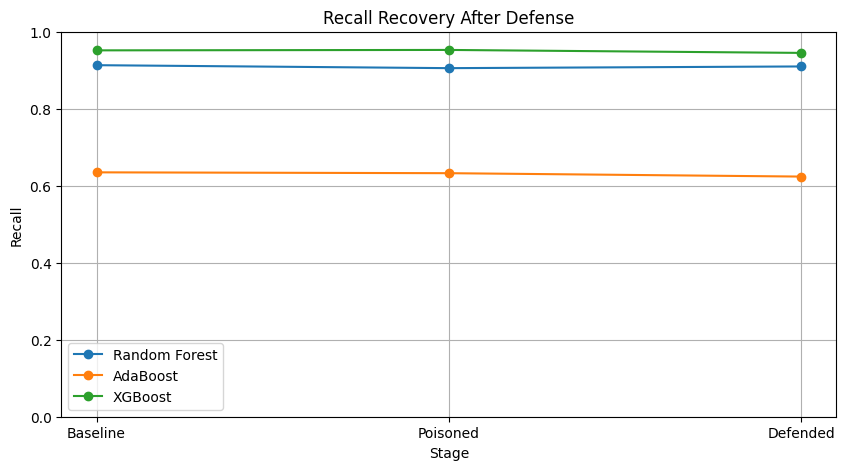

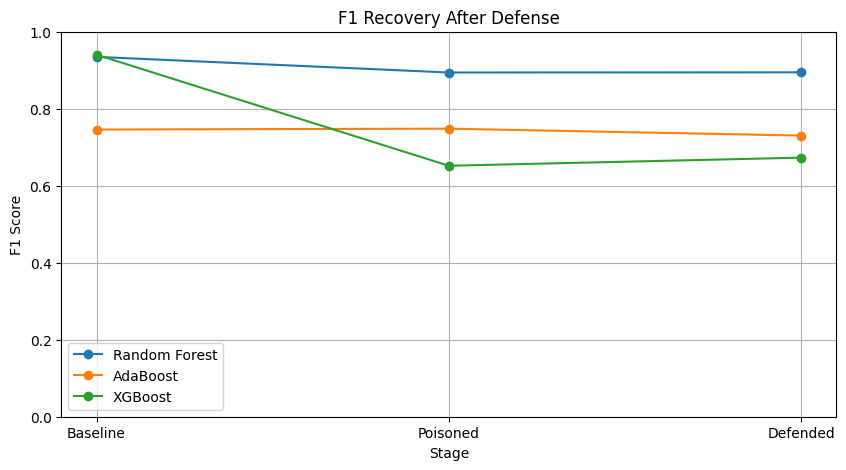

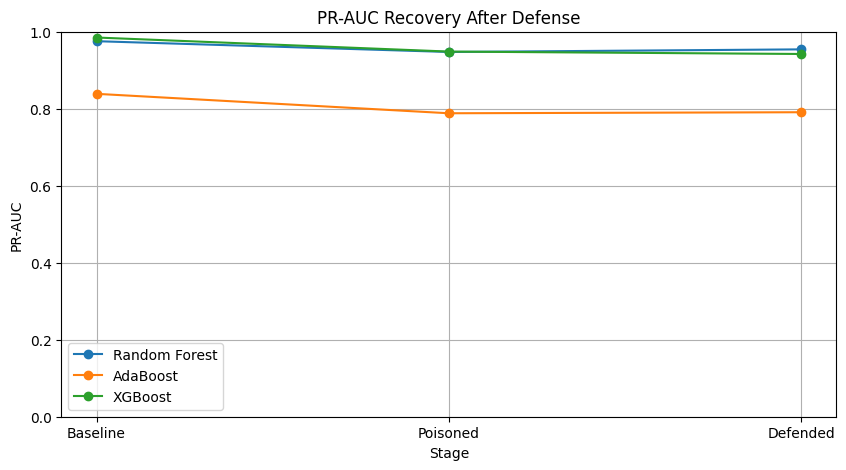

Defense and recovery stage completed.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)
from xgboost import XGBClassifier

# -----------------------------
# Create folders if needed
# -----------------------------
os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../results/models", exist_ok=True)

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("../data/processed/elliptic_clean.csv")

X = df.drop(columns=["label", "txId"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# -----------------------------
# Create poisoned labels
# -----------------------------
poison_rate = 0.20
y_train_poisoned = y_train.copy()

n_poison = int(len(y_train_poisoned) * poison_rate)
poison_indices = np.random.choice(y_train_poisoned.index, size=n_poison, replace=False)
y_train_poisoned.loc[poison_indices] = 1 - y_train_poisoned.loc[poison_indices]

X_train_poisoned = X_train.copy()

print("Poison rate:", poison_rate)
print("Number of flipped labels:", n_poison)

# -----------------------------
# Defense: Isolation Forest
# -----------------------------
iso = IsolationForest(
    n_estimators=100,
    contamination=poison_rate,
    random_state=42
)

anomaly_labels = iso.fit_predict(X_train_poisoned)

# Keep only normal samples
mask = anomaly_labels == 1
X_train_defended = X_train_poisoned[mask]
y_train_defended = y_train_poisoned[mask]

print("Original poisoned train shape:", X_train_poisoned.shape)
print("Filtered defended train shape:", X_train_defended.shape)

# -----------------------------
# Train defended Random Forest
# -----------------------------
rf_defended = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf_defended.fit(X_train_defended, y_train_defended)
rf_def_pred = rf_defended.predict(X_test)
rf_def_prob = rf_defended.predict_proba(X_test)[:, 1]

rf_def_precision = precision_score(y_test, rf_def_pred)
rf_def_recall = recall_score(y_test, rf_def_pred)
rf_def_f1 = f1_score(y_test, rf_def_pred)
rf_def_pr_auc = average_precision_score(y_test, rf_def_prob)

print("Defended Random Forest")
print("Precision:", rf_def_precision)
print("Recall:", rf_def_recall)
print("F1 Score:", rf_def_f1)
print("PR-AUC:", rf_def_pr_auc)
print(classification_report(y_test, rf_def_pred))

# -----------------------------
# Train defended AdaBoost
# -----------------------------
try:
    ada_defended = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    )
except TypeError:
    ada_defended = AdaBoostClassifier(
        base_estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    )

ada_defended.fit(X_train_defended, y_train_defended)
ada_def_pred = ada_defended.predict(X_test)
ada_def_prob = ada_defended.predict_proba(X_test)[:, 1]

ada_def_precision = precision_score(y_test, ada_def_pred)
ada_def_recall = recall_score(y_test, ada_def_pred)
ada_def_f1 = f1_score(y_test, ada_def_pred)
ada_def_pr_auc = average_precision_score(y_test, ada_def_prob)

print("Defended AdaBoost")
print("Precision:", ada_def_precision)
print("Recall:", ada_def_recall)
print("F1 Score:", ada_def_f1)
print("PR-AUC:", ada_def_pr_auc)
print(classification_report(y_test, ada_def_pred))

# -----------------------------
# Train defended XGBoost
# -----------------------------
scale_pos_weight_def = (y_train_defended == 0).sum() / (y_train_defended == 1).sum()

xgb_defended = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight_def
)

xgb_defended.fit(X_train_defended, y_train_defended)
xgb_def_pred = xgb_defended.predict(X_test)
xgb_def_prob = xgb_defended.predict_proba(X_test)[:, 1]

xgb_def_precision = precision_score(y_test, xgb_def_pred)
xgb_def_recall = recall_score(y_test, xgb_def_pred)
xgb_def_f1 = f1_score(y_test, xgb_def_pred)
xgb_def_pr_auc = average_precision_score(y_test, xgb_def_prob)

print("Defended XGBoost")
print("Precision:", xgb_def_precision)
print("Recall:", xgb_def_recall)
print("F1 Score:", xgb_def_f1)
print("PR-AUC:", xgb_def_pr_auc)
print(classification_report(y_test, xgb_def_pred))

# -----------------------------
# Confusion matrix counts
# -----------------------------
rf_cm = confusion_matrix(y_test, rf_def_pred)
ada_cm = confusion_matrix(y_test, ada_def_pred)
xgb_cm = confusion_matrix(y_test, xgb_def_pred)

rf_fp, rf_fn = rf_cm[0, 1], rf_cm[1, 0]
ada_fp, ada_fn = ada_cm[0, 1], ada_cm[1, 0]
xgb_fp, xgb_fn = xgb_cm[0, 1], xgb_cm[1, 0]

# -----------------------------
# Defense results table
# -----------------------------
defense_results = pd.DataFrame({
    "Scenario": ["After Defense", "After Defense", "After Defense"],
    "Model": ["Random Forest", "AdaBoost", "XGBoost"],
    "Precision": [rf_def_precision, ada_def_precision, xgb_def_precision],
    "Recall": [rf_def_recall, ada_def_recall, xgb_def_recall],
    "F1 Score": [rf_def_f1, ada_def_f1, xgb_def_f1],
    "PR-AUC": [rf_def_pr_auc, ada_def_pr_auc, xgb_def_pr_auc],
    "False Positives": [rf_fp, ada_fp, xgb_fp],
    "False Negatives": [rf_fn, ada_fn, xgb_fn]
})

print(defense_results)

# Save results
defense_results.to_csv("../results/tables/defense_results.csv", index=False)

# Save models
joblib.dump(rf_defended, "../results/models/random_forest_defended.pkl")
joblib.dump(ada_defended, "../results/models/adaboost_defended.pkl")
joblib.dump(xgb_defended, "../results/models/xgboost_defended.pkl")

# -----------------------------
# Compare baseline vs poisoned vs defended
# -----------------------------
baseline_results = pd.read_csv("../results/tables/baseline_results.csv")
poisoned_results = pd.read_csv("../results/tables/poisoned_results.csv")

baseline_results["Stage"] = "Baseline"
poisoned_results["Stage"] = "Poisoned"
defense_results["Stage"] = "Defended"

comparison_df = pd.concat([
    baseline_results[["Model", "Precision", "Recall", "F1 Score", "PR-AUC", "Stage"]],
    poisoned_results[["Model", "Precision", "Recall", "F1 Score", "PR-AUC", "Stage"]],
    defense_results[["Model", "Precision", "Recall", "F1 Score", "PR-AUC", "Stage"]]
])

print(comparison_df)

# Save comparison
comparison_df.to_csv("../results/tables/baseline_poisoned_defended_comparison.csv", index=False)

# -----------------------------
# Plot Recall comparison
# -----------------------------
plt.figure(figsize=(10, 5))
for model in comparison_df["Model"].unique():
    subset = comparison_df[comparison_df["Model"] == model]
    plt.plot(subset["Stage"], subset["Recall"], marker="o", label=model)

plt.xlabel("Stage")
plt.ylabel("Recall")
plt.title("Recall Recovery After Defense")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.savefig("../results/figures/defense_recovery_recall.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Plot F1 comparison
# -----------------------------
plt.figure(figsize=(10, 5))
for model in comparison_df["Model"].unique():
    subset = comparison_df[comparison_df["Model"] == model]
    plt.plot(subset["Stage"], subset["F1 Score"], marker="o", label=model)

plt.xlabel("Stage")
plt.ylabel("F1 Score")
plt.title("F1 Recovery After Defense")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.savefig("../results/figures/defense_recovery_f1.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Plot PR-AUC comparison
# -----------------------------
plt.figure(figsize=(10, 5))
for model in comparison_df["Model"].unique():
    subset = comparison_df[comparison_df["Model"] == model]
    plt.plot(subset["Stage"], subset["PR-AUC"], marker="o", label=model)

plt.xlabel("Stage")
plt.ylabel("PR-AUC")
plt.title("PR-AUC Recovery After Defense")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.savefig("../results/figures/defense_recovery_pr_auc.png", dpi=300, bbox_inches="tight")
plt.show()

print("Defense and recovery stage completed.")

In [5]:
plt.savefig("../results/figures/rf_baseline_top10_features.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>